In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
def load_data(file_path):
    """
    Load data from a CSV file.
    """
    return pd.read_csv(file_path)

In [3]:
df= load_data('2_preprocessed_encoded.csv')
df.head()

,age,fnlwgt,education,education-num,marital-status,occupation,relationship,race,capital-gain,capital-loss,...,target,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Unknown,workclass_Without-pay,sex_Male
0,3.688879,11.258253,12,13,0,0.136996,0.101617,0.254135,1,0,...,0,False,False,False,False,False,True,False,False,True
1,3.931826,11.330348,12,13,1,0.477803,0.448663,0.254135,0,0,...,0,False,False,False,False,True,False,False,False,True
2,3.663562,12.281398,8,9,0,0.066634,0.101617,0.254135,0,0,...,0,False,False,True,False,False,False,False,False,True
3,3.988984,12.366157,6,7,1,0.066634,0.448663,0.120863,0,0,...,0,False,False,True,False,False,False,False,False,True
4,3.367296,12.732013,12,13,1,0.451257,0.468897,0.120863,0,0,...,0,False,False,True,False,False,False,False,False,False


In [4]:
df.shape

(48790, 22)

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

# Your feature data (without target)
X = df.drop('target', axis=1)

# 1. Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Initialize PCA with variance threshold (0.95 = 95%)
pca = PCA(n_components=0.95)

# 3. Fit PCA
X_pca = pca.fit_transform(X_scaled)

# 4. Check how many components were chosen automatically
print(f'Number of components selected to explain 95% variance: {pca.n_components_}')

# 5. Explained variance ratio of each component
print(pca.explained_variance_ratio_)

# Now you have reduced features X_pca that explain 95% of the data variance
# 6. Create a DataFrame with PCA results
pca_df = pd.DataFrame(data=X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
# 7. Add target column back to the PCA DataFrame
pca_df['target'] = df['target'].values



Number of components selected to explain 95% variance: 17
[0.15174559 0.10431501 0.08032383 0.05559684 0.05284394 0.05073467
 0.05011166 0.04978192 0.04803674 0.04772013 0.04730768 0.04519586
 0.04269925 0.03992229 0.0394171  0.03548214 0.02847114]


In [8]:
pca_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,target
0,1.155418,-1.969264,1.730280,-0.733835,-0.803080,-1.956044,1.367700,3.838134,-0.961249,-0.132649,-0.644390,-0.130652,1.764252,2.243611,-1.410871,-0.207508,-0.567744,0
1,2.797184,-0.105704,1.803550,-1.351819,1.263417,-0.954391,-1.388272,0.165568,0.983416,-0.067077,0.729340,0.099256,0.383534,-1.705239,0.930118,-2.309653,-0.796845,0
2,-1.352032,0.295737,-0.597773,-0.194206,0.229178,0.102814,0.154162,-0.055728,0.171174,0.004125,0.169804,-0.233275,-0.292453,-0.008062,-0.534136,0.439476,-0.828434,0
3,-0.547865,2.603096,-0.334068,1.242077,-1.020523,-0.177172,-0.613181,0.427512,-0.211227,-0.085775,-0.276510,2.006113,-1.494398,-0.192370,-0.008581,-0.361066,-0.219699,0
4,1.012566,-1.106265,-1.114264,1.639383,-1.251121,0.066987,-0.639451,0.566884,0.505202,-0.135000,0.449498,1.781442,-1.251335,-0.670006,0.913757,-0.819277,1.590592,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48785,0.047564,-2.409668,-0.900851,0.072221,-0.002307,-0.113567,-0.060635,-0.136448,0.139924,-0.104134,0.282033,0.126723,0.495712,-1.133776,0.586136,0.538878,-0.074960,0
48786,-1.516348,0.369771,3.104157,0.411211,-2.019786,0.901700,0.335686,-0.144635,1.133979,-0.598146,0.944169,2.300420,-1.494392,0.963426,0.603813,1.381348,-1.909829,0
48787,2.255144,-0.223447,-1.589687,0.506574,-0.466261,0.424058,-0.131932,0.331664,0.829874,-0.019616,0.758539,-0.380968,-0.540402,-0.429712,0.161111,0.497706,0.013229,0
48788,0.397807,-1.356869,-0.811625,-1.073477,-0.673391,-2.065432,1.311000,-0.565543,0.245289,-0.055056,0.169065,0.445416,1.705717,1.608882,-0.609034,-0.278254,-1.061240,0


## KNN

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48790 entries, 0 to 48789
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         48790 non-null  float64
 1   fnlwgt                      48790 non-null  float64
 2   education                   48790 non-null  int64  
 3   education-num               48790 non-null  int64  
 4   marital-status              48790 non-null  int64  
 5   occupation                  48790 non-null  float64
 6   relationship                48790 non-null  float64
 7   race                        48790 non-null  float64
 8   capital-gain                48790 non-null  int64  
 9   capital-loss                48790 non-null  int64  
 10  hours-per-week              48790 non-null  int64  
 11  native-country              48790 non-null  float64
 12  target                      48790 non-null  int64  
 13  workclass_Local-gov         487

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, roc_curve, auc, RocCurveDisplay, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
X = df.drop("target", axis=1)
y = df["target"]

In [12]:
from imblearn.over_sampling import SMOTE

In [13]:
# Assume X = features, y = target
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Apply SMOTE only on the training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [14]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_resampled, y_train_resampled)

KNeighborsClassifier()

In [15]:
# 1️⃣ Cross-validation on resampled training data
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(knn, X_train_resampled, y_train_resampled, cv=cv, scoring='accuracy')
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

Cross-Validation Scores: [0.86375884 0.84742337 0.85011788 0.85062311 0.83813374 0.85177699
 0.84925046 0.85464039 0.84706081 0.84487115]
Mean CV Accuracy: 0.8497656741922442


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, validation_curve, learning_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
)

In [17]:

# 2️⃣ Hyperparameter tuning using GridSearchCV
param_grid = {'n_neighbors': np.arange(1, 21)}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=cv, scoring='accuracy')
grid.fit(X_train_resampled, y_train_resampled)

print("Best K:", grid.best_params_['n_neighbors'])
print("Best CV Accuracy:", grid.best_score_)

Best K: 1
Best CV Accuracy: 0.8730250798308704


In [18]:
# Use best model
best_knn = grid.best_estimator_
best_knn.fit(X_train_resampled, y_train_resampled)

KNeighborsClassifier(n_neighbors=1)

In [20]:
# 4️⃣ Evaluation on test set
y_pred = best_knn.predict(X_test)
y_proba = best_knn.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Test Accuracy: 0.7937077269932363
Precision: 0.5580309019044197
Recall: 0.6648116438356164
F1 Score: 0.6067591326430943


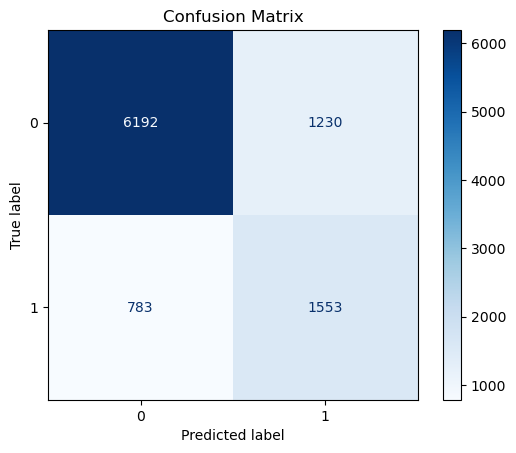

In [21]:
# 5️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


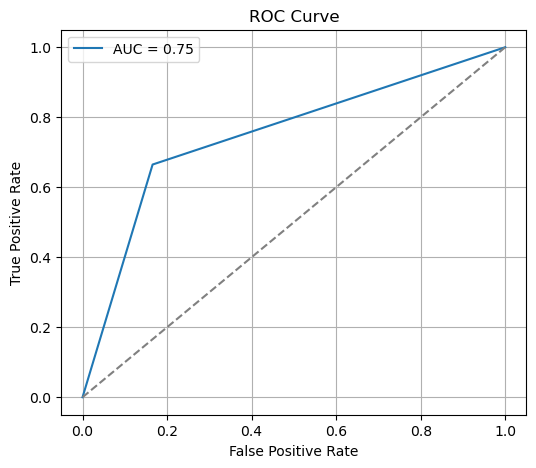

In [22]:
# 6️⃣ ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [24]:
#classification_report
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred, target_names=['<=50k', '>50k'])
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

       <=50k       0.89      0.83      0.86      7422
        >50k       0.56      0.66      0.61      2336

    accuracy                           0.79      9758
   macro avg       0.72      0.75      0.73      9758
weighted avg       0.81      0.79      0.80      9758

